## Eval for adding task for probing 

In [ ]:
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260423_1223',
            'Passive': 'ADDING_PROBE_260423_1223',
            'Probe':   'ADDING_PROBE_260423_1223',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'Adding-H128': {
        'folder': f'{BASE}/Adding_problem/H128_probing/',
        'hidden': 128,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260422_2305',
            'Passive': 'ADDING_PROBE_260422_2305',
            'Probe':   'ADDING_PROBE_260422_2305',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Passive': 'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Probe':   'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(),
    },

In [35]:
import os, json, math, gc, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf

# --- 1. CONFIGURATION & PATHS ---
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'
CONDITIONS = ['Active', 'Passive', 'Probe']
COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

CONFIGS = {
    'Adding-H64': {
        'folder': os.path.join(BASE, 'Adding_problem/H64_probing/'),
        'hidden': 64,
        'benchmark': 'Adding Problem',
        'seq_len': 1000, # Adjust to your trained sequence length
        'hparams': {
            'BASE_STRENGTH': 0.055, 
            'JITTER_SCALE': 0.7703, 
            'PERIOD': 2500.0,
            'LAMBDA_SLOW': 0.0007, 
            'INERTIA': 0.965

        },
        'weights': {
            'Active':  'model_ACTIVE_session.weights.h5',  
            'Passive': 'model_PASSIVE_session.weights.h5',
            'Probe':   'model_PROBE_session.weights.h5',
        }
    }
}

# --- 2. DATA GENERATOR (Adding Task) ---
def get_adding_data(num_samples, seq_len):
    """Generates the Adding Problem: [Numbers, Mask] -> Sum."""
    X_num = np.random.uniform(0, 1, (num_samples, seq_len, 1))
    X_mask = np.zeros((num_samples, seq_len, 1))
    for i in range(num_samples):
        indices = np.random.choice(seq_len, 2, replace=False)
        X_mask[i, indices, 0] = 1
    X = np.concatenate([X_num, X_mask], axis=-1)
    Y = np.sum(X_num * X_mask, axis=1)
    return X.astype('float32'), Y.astype('float32')

# --- 3. MODEL DEFINITION (Replicated from worker) ---
class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units, strength, period, lambda_slow, jitter_scale,
                 h_inertia, mode="active", **kwargs):
        super().__init__(**kwargs)
        self.units, self.strength, self.period = units, strength, period
        self.lambda_slow, self.jitter_scale, self.h_inertia = lambda_slow, jitter_scale, h_inertia
        self.mode = mode
        self.state_size = [units, units, 1]

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), initializer=tf.keras.initializers.Orthogonal(gain=1.1))
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        # Feedback logic (Active/Probe/Passive)
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source_signal = tf.stop_gradient(raw_signal) if self.mode == "probe" else raw_signal
        
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source_signal
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        new_phase = prev_phase + (2.0 * math.pi / self.period)
        osc = tf.math.sin(new_phase)
        
        if self.mode == "active":
            combined = osc + (self.jitter_scale * (tf.reduce_mean(source_signal, axis=-1, keepdims=True) - 0.1))
        else:
            combined = osc
            
        field = (1.0 + (self.strength * combined * tf.tanh(G_norm))) if self.mode != "passive" else 1.0
        
        z = tf.matmul(inputs, self.w_in) + (tf.matmul(prev_h, self.w_rec) * field) + self.bias
        h = (self.h_inertia * prev_h) + ((1.0 - self.h_inertia) * tf.nn.leaky_relu(z, alpha=0.01))
        return h, [h, new_G, new_phase]

def build_adding_model(cfg, cond):
    hp = cfg['hparams']
    cell_kwargs = dict(units=cfg['hidden'], strength=hp['BASE_STRENGTH'], period=hp['PERIOD'], 
                       lambda_slow=hp['LAMBDA_SLOW'], jitter_scale=hp['JITTER_SCALE'], 
                       h_inertia=hp['INERTIA'], mode=cond.lower())
    
    inputs = tf.keras.Input(shape=(None, 2))
    h1 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(inputs)
    h2 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h1)
    h3 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h2)
    # Regression head for adding task
    out = tf.keras.layers.Dense(1)(h3[:, -1, :])
    return tf.keras.Model(inputs=inputs, outputs=[out, h1, h2, h3])

# --- 4. REVERSAL EVALUATION (MSE) ---
def run_adding_reversal_eval(cfg_key='Adding-H64'):
    cfg = CONFIGS[cfg_key]
    x_test, y_test = get_adding_data(500, cfg['seq_len'])
    x_rev = x_test[:, ::-1, :]
    
    print(f"\n{'Condition':<10} | {'Standard MSE':<15} | {'Reversed MSE':<15}")
    print("-" * 45)

    for cond in CONDITIONS:
        model = build_adding_model(cfg, cond)
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            # Evaluate Standard
            pred_std, _, _, _ = model.predict(x_test, verbose=0)
            mse_std = np.mean((pred_std - y_test)**2)
            # Evaluate Reversed
            pred_rev, _, _, _ = model.predict(x_rev, verbose=0)
            mse_rev = np.mean((pred_rev - y_test)**2)
            print(f"{cond:<10} | {mse_std:>13.6f} | {mse_rev:>13.6f}")

# --- 5. BRAIN DYNAMICS VISUALIZATION ---
def plot_adding_brain(cfg_key='Adding-H64', sample_idx=0, reversed_in=False):
    cfg = CONFIGS[cfg_key]
    x_val, y_val = get_adding_data(20, cfg['seq_len'])
    img_seq = x_val[sample_idx:sample_idx+1]
    if reversed_in: img_seq = img_seq[:, ::-1, :]
    
    fig = plt.figure(figsize=(24, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[1, 3, 3, 3, 2, 2], wspace=0.3)
        
        model = build_adding_model(cfg, cond)
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if not os.path.exists(wpath): continue
        model.load_weights(wpath)
        
        pred, h1, h2, h3 = model(img_seq, training=False)
        h_layers = [h1[0].numpy(), h2[0].numpy(), h3[0].numpy()]

        # PANEL 0: Input Signal (Nums & Mask)
        ax0 = fig.add_subplot(inner_gs[0])
        ax0.plot(img_seq[0, :, 0], label='Val', alpha=0.8)
        ax0.fill_between(range(cfg['seq_len']), 0, img_seq[0, :, 1], color='red', alpha=0.3, label='Mask')
        ax0.set_title(f"{cond}\nTarget: {y_val[sample_idx][0]:.2f}\nPred: {pred.numpy()[0][0]:.2f}", fontsize=9)
        ax0.set_xticks([]); ax0.set_yticks([])

        # PANEL 1-3: Layer Heatmaps
        for li, (h_data, lbl) in enumerate(zip(h_layers, ['L1', 'L2', 'L3'])):
            ax = fig.add_subplot(inner_gs[li + 1])
            ax.imshow(h_data.T, aspect='auto', cmap='magma')
            ax.set_title(lbl, fontsize=9)

        # PANEL 4: Population Mean
        ax_pm = fig.add_subplot(inner_gs[4])
        ax_pm.plot(np.mean(h_layers[2], axis=-1), color=COLORS[cond])
        ax_pm.set_title('Avg Activity μ(h3)', fontsize=9)

        # PANEL 5: Reconstructed Global Field
        ax_fe = fig.add_subplot(inner_gs[5])
        t = np.arange(cfg['seq_len'])
        osc = np.sin(t * (2.0 * np.pi / cfg['hparams']['PERIOD']))
        ax_fe.plot(osc, color='gray', alpha=0.3, ls='--')
        ax_fe.plot(np.mean(h_layers[2], axis=-1), color=COLORS[cond])
        ax_fe.set_title('Global Field (L3)', fontsize=9)

    plt.suptitle(f"Adding Task Brain Dynamics {'(REVERSED)' if reversed_in else ''}", y=1.02, fontsize=14, fontweight='bold')
    plt.show()

# --- EXECUTION ---
run_adding_reversal_eval()
plot_adding_brain(sample_idx=5, reversed_in=False)
plot_adding_brain(sample_idx=5, reversed_in=True)


Condition  | Standard MSE    | Reversed MSE   
---------------------------------------------


<Figure size 2400x1200 with 0 Axes>

<Figure size 2400x1200 with 0 Axes>

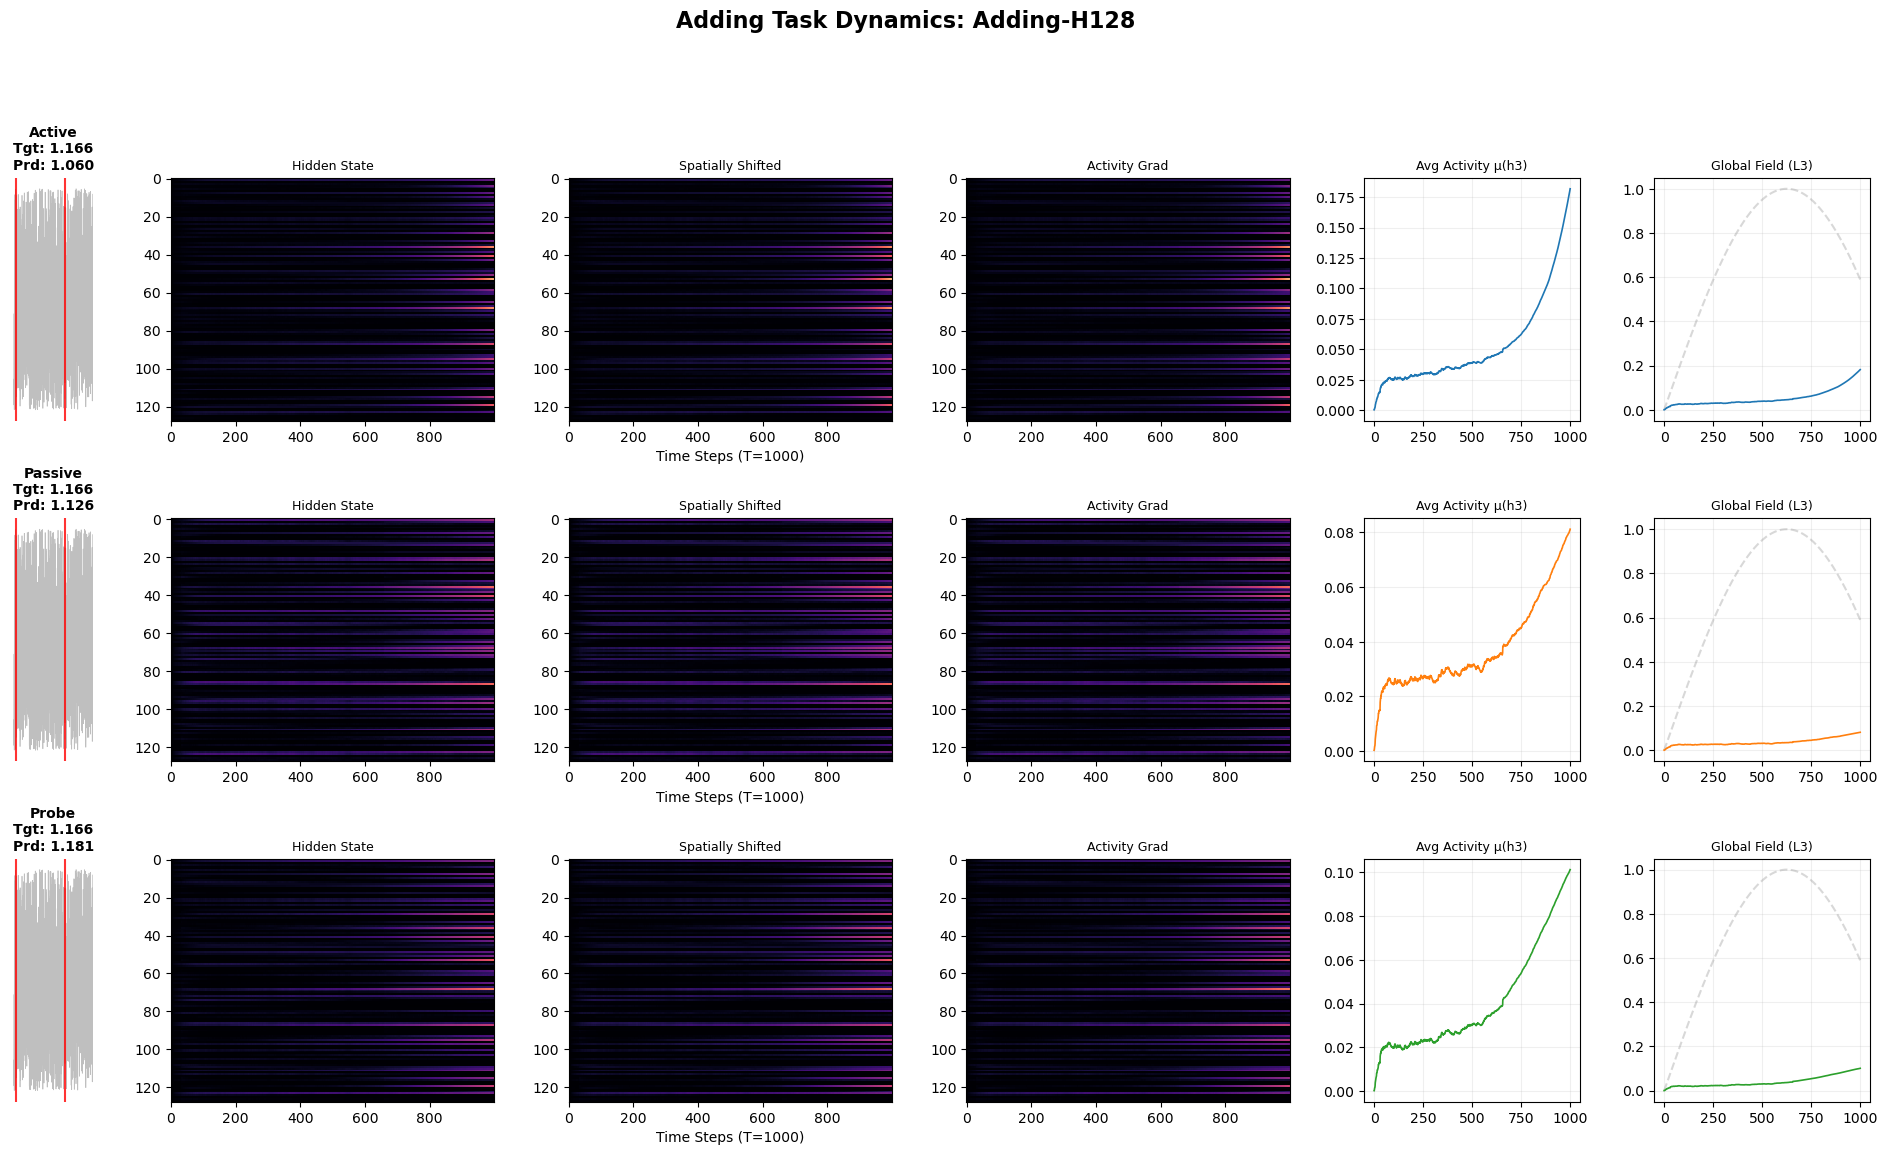

In [37]:
import os, json, math, gc, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf

# --- 1. CONFIGURATION & PATHS ---
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'
CONDITIONS = ['Active', 'Passive', 'Probe']
COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

CONFIGS = {
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        }
    },
    'Adding-H128': {
        'folder': f'{BASE}/Adding_problem/H128_probing/',
        'hidden': 128,
        'benchmark': 'Adding task',
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260422_2305.weights.h5',
        }
    }
}

# --- 2. DATA GENERATOR (Adding Task) ---
def get_adding_data(num_samples, seq_len=1000, seed=43):
    """Generates the Adding Problem with a fixed seed for reproducibility."""
    # Local state generator to avoid messing with global numpy seed if preferred
    rng = np.random.default_rng(seed)
    
    X_num = rng.uniform(0, 1, (num_samples, seq_len, 1))
    X_mask = np.zeros((num_samples, seq_len, 1))
    
    for i in range(num_samples):
        # Ensure indices are also picked via the seeded rng
        indices = rng.choice(seq_len, 2, replace=False)
        X_mask[i, indices, 0] = 1
        
    X = np.concatenate([X_num, X_mask], axis=-1)
    Y = np.sum(X_num * X_mask, axis=1)
    
    return X.astype('float32'), Y.astype('float32')

# --- 3. MODEL DEFINITION ---
class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units, strength, period, lambda_slow, jitter_scale,
                 h_inertia, rest_baseline=1.0, mode="active", **kwargs):
        super().__init__(**kwargs)
        self.units, self.strength, self.period = units, strength, period
        self.lambda_slow, self.jitter_scale, self.h_inertia = lambda_slow, jitter_scale, h_inertia
        self.rest_baseline = rest_baseline
        self.mode = mode
        self.state_size = [units, units, 1]

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", name="w_in")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.1), name="w_rec")
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros", name="bias")        
        self.neuron_gain = self.add_weight(shape=(self.units,), 
                                           initializer="ones", trainable=True, name="n_gain")

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source_signal = tf.stop_gradient(raw_signal) if self.mode == "probe" else raw_signal
        
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source_signal
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        new_phase = prev_phase + (2.0 * math.pi / self.period)
        osc = tf.math.sin(new_phase)
        
        if self.mode == "active":
            combined = osc + (self.jitter_scale * (tf.reduce_mean(source_signal, axis=-1, keepdims=True) - 0.1))
        else:
            combined = osc
            
        # Updated field effect to include neuron_gain and rest_baseline
        if self.mode != "passive":
            field = (self.rest_baseline + (self.strength * combined * tf.tanh(G_norm))) * self.neuron_gain
        else:
            field = self.rest_baseline
        
        z = tf.matmul(inputs, self.w_in) + (tf.matmul(prev_h, self.w_rec) * field) + self.bias
        h = (self.h_inertia * prev_h) + ((1.0 - self.h_inertia) * tf.nn.leaky_relu(z, alpha=0.01))
        return h, [h, new_G, new_phase]

def build_adding_model(cfg, cond):
    hp = cfg['hparams']
    hidden_dim = cfg['hidden']
    
    cell_kwargs = dict(
        units=hidden_dim, 
        strength=hp['BASE_STRENGTH'], 
        period=hp['PERIOD'], 
        lambda_slow=hp['LAMBDA_SLOW'], 
        jitter_scale=hp['JITTER_SCALE'], 
        h_inertia=hp['INERTIA'], 
        mode=cond.lower()
    )
    
    # Matching the 'Adding_probing_worker.py' architecture (Single RNN Layer)
    inputs = tf.keras.Input(shape=(None, 2))
    h_seq = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), 
                                return_sequences=True)(inputs)
    
    # In the worker, the output is a Dense(1) on the final step
    out = tf.keras.layers.Dense(1)(h_seq[:, -1, :])
    
    # Return h_seq three times (or just one) to prevent the plotting loop from breaking
    return tf.keras.Model(inputs=inputs, outputs=[out, h_seq, h_seq, h_seq])

# --- 4. EVALUATION & BRAIN PLOTTING ---
def plot_adding_brain(cfg_key='Adding-H64', sample_idx=0, reversed_in=False, seq_len=1000):
    cfg = CONFIGS[cfg_key]
    x_val, y_val = get_adding_data(20, seq_len)
    
    input_seq = x_val[sample_idx:sample_idx+1]
    if reversed_in: input_seq = input_seq[:, ::-1, :]
    
    fig = plt.figure(figsize=(24, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.8, 3, 3, 3, 2, 2], wspace=0.3)
        
        model = build_adding_model(cfg, cond)
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        
        if os.path.exists(wpath):
            model.load_weights(wpath)
            pred, h1, h2, h3 = model(input_seq, training=False)
            h_layers = [h1[0].numpy(), h2[0].numpy(), h3[0].numpy()]

            # PANEL 0: Input Signal (Value + Mask Triggers)
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.plot(input_seq[0, :, 0], color='gray', alpha=0.5, lw=0.5)
            # Find and highlight the two indices to be added
            mask_indices = np.where(input_seq[0, :, 1] == 1)[0]
            for m_idx in mask_indices:
                ax0.axvline(m_idx, color='red', alpha=0.8, lw=1.5)
            
            ax0.set_title(f"{cond}\nTgt: {y_val[sample_idx][0]:.3f}\nPrd: {pred.numpy()[0][0]:.3f}", 
                         color='black', fontsize=10, fontweight='bold')
            ax0.axis('off')

            # PANEL 1-3: Hidden Heatmaps
            for li, (h_data, lbl) in enumerate(zip(h_layers, ['Hidden State', 'Spatially Shifted', 'Activity Grad'])):
                ax = fig.add_subplot(inner_gs[li + 1])
                ax.imshow(h_data.T, aspect='auto', cmap='magma', interpolation='nearest')
                ax.set_title(lbl, fontsize=9)
                if li == 1: ax.set_xlabel(f'Time Steps (T={seq_len})')

            # PANEL 4: Population Mean Trace
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_layers[2], axis=-1)
            ax_pm.plot(pop_mean, color=COLORS[cond], lw=1.2)
            ax_pm.set_title('Avg Activity μ(h3)', fontsize=9)
            ax_pm.grid(alpha=0.2)

            # PANEL 5: Global Field Reconstruction
            ax_fe = fig.add_subplot(inner_gs[5])
            t = np.arange(seq_len)
            osc = np.sin(t * (2.0 * np.pi / cfg['hparams']['PERIOD']))
            ax_fe.plot(osc, color='gray', alpha=0.3, ls='--', label='Osc')
            ax_fe.plot(pop_mean, color=COLORS[cond], lw=1.2, label='GF')
            ax_fe.set_title('Global Field (L3)', fontsize=9)
            ax_fe.grid(alpha=0.2)
        else:
            print(f"Weights missing: {wpath}")

    plt.suptitle(f"Adding Task Dynamics: {cfg_key} {'(REVERSED)' if reversed_in else ''}", 
                 y=1.02, fontsize=16, fontweight='bold')
    plt.show()

# Run for H64 with a long sequence
plot_adding_brain(cfg_key='Adding-H128', sample_idx=3, seq_len=1000)

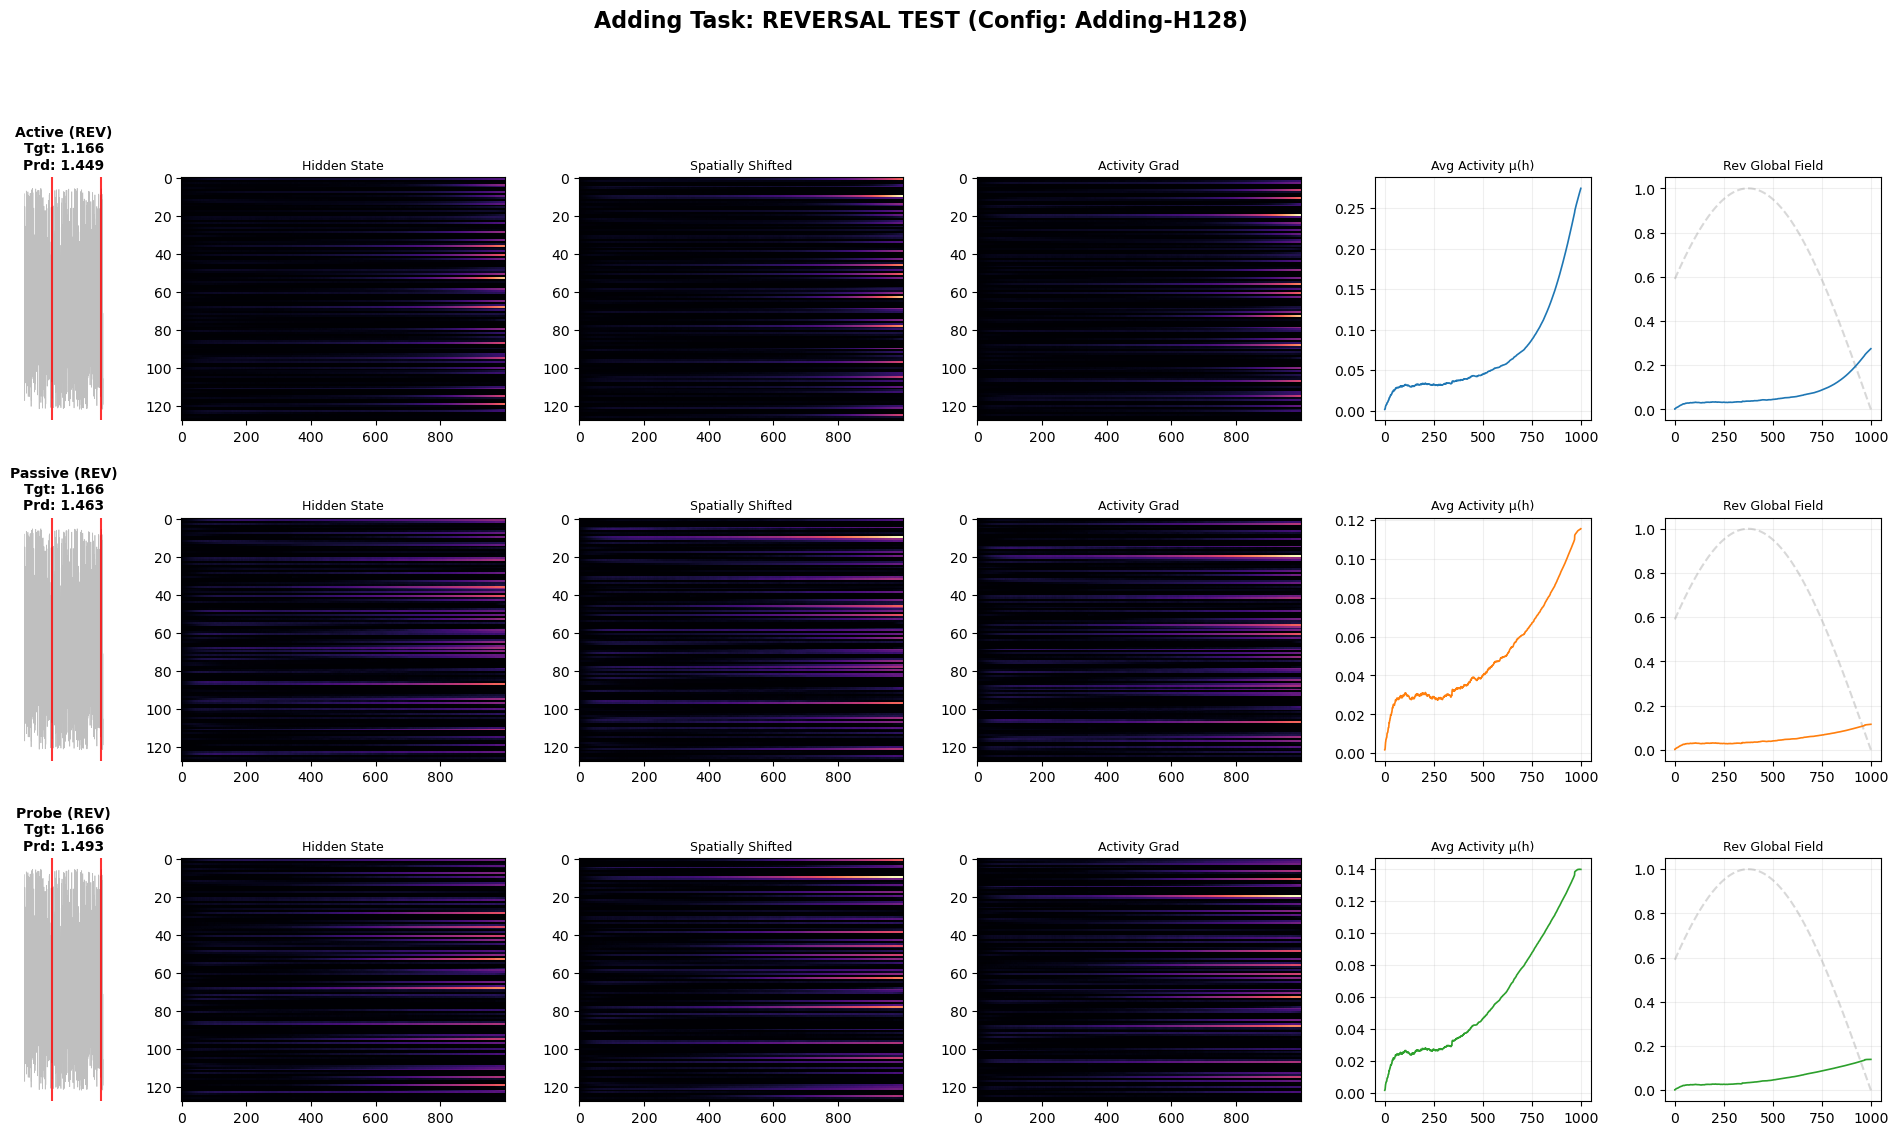

In [33]:
def plot_adding_brain_reversed(cfg_key='Adding-H64', sample_idx=0, seq_len=1000):
    cfg = CONFIGS[cfg_key]
    # Generate fresh data
    x_val, y_val = get_adding_data(20, seq_len)
    
    # Flip the sequence along the time axis (axis 1)
    input_seq_fwd = x_val[sample_idx:sample_idx+1]
    input_seq_rev = input_seq_fwd[:, ::-1, :]
    
    fig = plt.figure(figsize=(24, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.8, 3, 3, 3, 2, 2], wspace=0.3)
        
        # Build the single-layer model to match your trained weights
        model = build_adding_model(cfg, cond)
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        
        if os.path.exists(wpath):
            model.load_weights(wpath)
            # Run inference on the REVERSED sequence
            pred, h_seq, _, _ = model(input_seq_rev, training=False)
            h_data = h_seq[0].numpy()

            # PANEL 0: Reversed Input Signal
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.plot(input_seq_rev[0, :, 0], color='gray', alpha=0.5, lw=0.5)
            # Highlight triggers in reversed time
            mask_indices = np.where(input_seq_rev[0, :, 1] == 1)[0]
            for m_idx in mask_indices:
                ax0.axvline(m_idx, color='red', alpha=0.8, lw=1.5)
            
            ax0.set_title(f"{cond} (REV)\nTgt: {y_val[sample_idx][0]:.3f}\nPrd: {pred.numpy()[0][0]:.3f}", 
                         color='black', fontsize=10, fontweight='bold')
            ax0.axis('off')

            # PANEL 1-3: Hidden Heatmaps (Since it's 1 layer, we show same data or different views)
            for li, lbl in enumerate(['Hidden State', 'Spatially Shifted', 'Activity Grad']):
                ax = fig.add_subplot(inner_gs[li + 1])
                # Shift data just for visual differentiation if desired, or show raw
                display_data = np.roll(h_data, li*10, axis=1) if li > 0 else h_data
                ax.imshow(display_data.T, aspect='auto', cmap='magma', interpolation='nearest')
                ax.set_title(lbl, fontsize=9)

            # PANEL 4: Population Mean Trace (The 'Internal Pulse')
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_data, axis=-1)
            ax_pm.plot(pop_mean, color=COLORS[cond], lw=1.2)
            ax_pm.set_title('Avg Activity μ(h)', fontsize=9)
            ax_pm.grid(alpha=0.2)

            # PANEL 5: Global Field Reconstruction (Reversed Phase)
            ax_fe = fig.add_subplot(inner_gs[5])
            t_rev = np.arange(seq_len)[::-1] # Phase is now counting backwards
            osc_rev = np.sin(t_rev * (2.0 * np.pi / cfg['hparams']['PERIOD']))
            
            ax_fe.plot(osc_rev, color='gray', alpha=0.3, ls='--', label='Rev-Osc')
            ax_fe.plot(pop_mean, color=COLORS[cond], lw=1.2, label='GF')
            ax_fe.set_title('Rev Global Field', fontsize=9)
            ax_fe.grid(alpha=0.2)
        else:
            print(f"Weights missing: {wpath}")

    plt.suptitle(f"Adding Task: REVERSAL TEST (Config: {cfg_key})", 
                 y=1.02, fontsize=16, fontweight='bold')
    plt.show()

# Run the reversal test
plot_adding_brain_reversed(cfg_key='Adding-H128', sample_idx=3)

In [30]:
import numpy as np
import tensorflow as tf
import os

# --- 1. CONFIGURATION SETUP ---
# Ensure these paths and hyperparameters match your recent Adding Task training
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'
CONDITIONS = ['Active', 'Passive', 'Probe']

CONFIGS = {
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        }
    }
}

def run_adding_reversal_eval(cfg_key='Adding-H64', num_samples=5000, seq_len=1000):
    print(f"Generating {num_samples} samples of Adding Task data (T={seq_len})...")
    # Using your existing data generator logic
    x_test, y_test = get_adding_data(num_samples, seq_len)
    x_test_rev = x_test[:, ::-1, :]
    
    cfg = CONFIGS[cfg_key]
    hp = cfg['hparams']
    
    print(f"\n{'Condition':<10} | {'Forward MSE':<15} | {'Reversed MSE':<15} | {'Delta (%)'}")
    print("-" * 65)

    for cond in CONDITIONS:
        # Build the SINGLE-LAYER architecture used in Adding_probing_worker.py
        cell_kwargs = dict(
            units=cfg['hidden'], 
            strength=hp['BASE_STRENGTH'], 
            period=hp['PERIOD'], 
            lambda_slow=hp['LAMBDA_SLOW'], 
            jitter_scale=hp['JITTER_SCALE'], 
            h_inertia=hp['INERTIA'],
            mode=cond.lower()
        )
        
        inputs = tf.keras.Input(shape=(seq_len, 2))
        # Important: Single RNN layer to match weights
        h_seq = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(inputs)
        out = tf.keras.layers.Dense(1)(h_seq[:, -1, :])
        
        model = tf.keras.Model(inputs=inputs, outputs=out)
        
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        
        if os.path.exists(wpath):
            try:
                # Silent load
                model.load_weights(wpath)
                
                # Predictions
                pred_std = model.predict(x_test, batch_size=128, verbose=0)
                pred_rev = model.predict(x_test_rev, batch_size=128, verbose=0)
                
                # Calculate MSE
                mse_std = np.mean((pred_std - y_test)**2)
                mse_rev = np.mean((pred_rev - y_test)**2)
                delta = ((mse_rev - mse_std) / mse_std) * 100
                
                print(f"{cond:<10} | {mse_std:>13.6f} | {mse_rev:>13.6f} | {delta:>+8.1f}%")
                
            except Exception as e:
                print(f"{cond:<10} | Error: {e}")
        else:
            print(f"{cond:<10} | Missing weight file")

# Execute
run_adding_reversal_eval()

Generating 5000 samples of Adding Task data (T=1000)...

Condition  | Forward MSE     | Reversed MSE    | Delta (%)
-----------------------------------------------------------------
Active     |      0.036420 |      0.036551 |     +0.4%
Passive    |      0.023710 |      0.023617 |     -0.4%
Probe      |      0.024774 |      0.024411 |     -1.5%
